In [25]:
import numpy as np
import pandas as pd
import pyxdf
import mne

In [26]:
data, header = pyxdf.load_xdf("../lab_recorder_data/sub-demo_ses-demo_task-Default_run-001_eeg.xdf")
for i, stream in enumerate(data):
    print(f"Stream {i}: {stream['info']['name'][0]}")

Stream 0: PsychoPyMarkers
Stream 1: PsychoPy_numeric
Stream 2: EEG_LIFU_events
Stream 3: EEG_gpype


In [27]:
def _load_streams():
    """Load all streams from the .xdf file and return by name."""
    #data, _ = pyxdf.load_xdf(str(XDF_PATH))
    return {s["info"]["name"][0]: s for s in data}
streams = _load_streams()
streams['EEG_LIFU_events']

{'info': defaultdict(list,
             {'name': ['EEG_LIFU_events'],
              'type': ['Markers'],
              'channel_count': ['1'],
              'channel_format': ['string'],
              'source_id': [None],
              'nominal_srate': ['0.000000000000000'],
              'version': ['1.100000000000000'],
              'created_at': ['2215451.548302000'],
              'uid': ['c6a07abb-000b-4dbb-9f98-c6fe4227dc70'],
              'session_id': ['default'],
              'hostname': ['JanetsPC'],
              'v4address': [None],
              'v4data_port': ['16572'],
              'v4service_port': ['16572'],
              'v6address': [None],
              'v6data_port': ['16572'],
              'v6service_port': ['16572'],
              'desc': [None],
              'stream_id': 1,
              'effective_srate': 0,
              'segments': [(0, 8)],
              'clock_segments': [(0, 8)]}),
 'time_series': [['START_EXPERIMENT_RECEIVED'],
  ['LIFU_ON'],
  ['LI

In [28]:
stream = data[3]
df= []
df = pd.DataFrame(stream['time_series'])
df = df.rename(columns={i: f"Ch{i}" for i in range(df.shape[1])})

# Add timestamp column
df['Timestamp'] = stream['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in df.columns if col != 'Timestamp']
df = df[cols]
eeg_raw = df[['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch12','Timestamp']]
eeg_raw

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp
0,199999.968750,-154367.796875,-137246.468750,105088.875000,-69586.921875,72173.359375,110576.109375,-0.059788,2.215539e+06
1,199999.968750,-153008.843750,-140120.921875,107280.273438,-71461.976562,64322.835938,109229.226562,-0.213962,2.215539e+06
2,199999.968750,-152886.218750,-140737.000000,106887.351562,-71964.484375,63257.742188,108986.359375,-0.433065,2.215539e+06
3,199999.968750,-154135.750000,-137938.250000,104820.414062,-70163.976562,70691.851562,110274.210938,-0.661341,2.215539e+06
4,199999.968750,-154415.250000,-136931.328125,104936.226562,-69384.898438,72877.000000,110730.585938,-0.803524,2.215539e+06
...,...,...,...,...,...,...,...,...,...
43280,192072.828125,27669.527344,58498.054688,199999.968750,98115.109375,198460.546875,199999.968750,-0.120704,2.215712e+06
43281,190093.750000,26805.021484,60611.250000,199999.968750,98883.664062,199999.968750,199999.968750,-0.057357,2.215712e+06
43282,198280.593750,29018.855469,51713.492188,199999.968750,96442.671875,194953.125000,199999.968750,-0.032946,2.215712e+06
43283,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.201772,2.215712e+06


In [29]:
trial_data = data[0]
# Create DataFrame from time_series
trial_df = pd.DataFrame(trial_data['time_series'])

# Rename the first column to 'markers'
trial_df.rename(columns={0: 'markers'}, inplace=True)

# Add timestamp column
trial_df['Timestamp'] = trial_data['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in trial_df.columns if col != 'Timestamp']
trial_df = trial_df[cols]
trial_df

,Timestamp,markers
0,2.215584e+06,START_EXPERIMENT
1,2.215586e+06,START_EXPERIMENT
2,2.215588e+06,START_EXPERIMENT
3,2.215590e+06,START_EXPERIMENT
4,2.215592e+06,START_EXPERIMENT
...,...,...
63,2.215710e+06,START_EXPERIMENT
64,2.215712e+06,START_EXPERIMENT
65,2.215714e+06,START_EXPERIMENT
66,2.215716e+06,START_EXPERIMENT


In [30]:
trial_ts = np.array(trial_df['Timestamp'])
trial_ts

array([2215583.79124099, 2215585.77410444, 2215587.76881768,
       2215589.76134153, 2215591.75398058, 2215593.74719093,
       2215595.75142257, 2215597.75325262, 2215599.76068987,
       2215601.75415121, 2215603.75623616, 2215605.74944811,
       2215607.75065206, 2215609.7518351 , 2215611.77121625,
       2215613.7631558 , 2215615.75695634, 2215617.74986509,
       2215619.75227794, 2215621.75478458, 2215623.75580693,
       2215625.75000488, 2215627.75124943, 2215629.75118557,
       2215631.75328632, 2215633.75596397, 2215635.74880221,
       2215637.76262346, 2215639.76273321, 2215641.76793405,
       2215643.7646717 , 2215645.76338915, 2215647.75931119,
       2215649.75063984, 2215651.75316509, 2215653.75770744,
       2215655.75483518, 2215657.74987673, 2215659.75153118,
       2215661.76198712, 2215663.76223377, 2215665.75648112,
       2215667.74944717, 2215669.75147561, 2215671.75303116,
       2215673.77166011, 2215675.76553405, 2215677.7573016 ,
       2215679.75108775,

In [31]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Match trial_ts (LSL timestamps) to closest sample index in eeg_raw
# ---------------------------------------------------------------------------
# Assumes:
#   - trial_ts: array-like of LSL timestamps to match (e.g. lifu_on, or any
#     other event-time array on the same LSL clock)
#   - eeg_raw:  DataFrame with a 'Timestamp' column (LSL time), same clock

timestamps = eeg_raw['Timestamp'].values
trial_ts = np.asarray(trial_ts)

# --- vectorized nearest-timestamp match ---
insert_idx = np.searchsorted(timestamps, trial_ts)
insert_idx = np.clip(insert_idx, 1, len(timestamps) - 1)

left_vals = timestamps[insert_idx - 1]
right_vals = timestamps[insert_idx]

use_left = np.abs(trial_ts - left_vals) < np.abs(trial_ts - right_vals)
matched_idx = np.where(use_left, insert_idx - 1, insert_idx)

# --- sanity check match quality ---
matched_time = timestamps[matched_idx]
time_diff = matched_time - trial_ts  # signed: negative = eeg sample before event, positive = after

fs = 1 / np.median(np.diff(timestamps))  # estimate actual sampling rate from data
expected_max_diff = 0.5 / fs  # half a sample period

n_bad = np.sum(np.abs(time_diff) > expected_max_diff)
if n_bad > 0:
    print(f"Warning: {n_bad} of {len(trial_ts)} matches exceed half a sample period "
          f"({expected_max_diff*1000:.2f} ms). Check for stream dropouts or clock offset.")
else:
    print(f"All {len(trial_ts)} matches within expected tolerance "
          f"({expected_max_diff*1000:.2f} ms), estimated fs = {fs:.2f} Hz.")

trial_index_df = pd.DataFrame({
    'trial_ts': trial_ts,
    'matched_index': matched_idx,
    'matched_timestamp': matched_time,
    'time_diff_sec': time_diff,
})
trial_index_df

,trial_ts,matched_index,matched_timestamp,time_diff_sec
0,2.215584e+06,11247,2.215584e+06,0.000184
1,2.215586e+06,11742,2.215586e+06,-0.001021
2,2.215588e+06,12241,2.215588e+06,0.001938
3,2.215590e+06,12738,2.215590e+06,-0.000921
4,2.215592e+06,13236,2.215592e+06,0.000108
...,...,...,...,...
63,2.215710e+06,42717,2.215710e+06,0.001520
64,2.215712e+06,43216,2.215712e+06,-0.001819
65,2.215714e+06,43284,2.215712e+06,-1.722460
66,2.215716e+06,43284,2.215712e+06,-3.716384


In [32]:
trials = np.array(trial_index_df['matched_index'])
trials

array([11247, 11742, 12241, 12738, 13236, 13734, 14234, 14735, 15236,
       15734, 16234, 16732, 17232, 17732, 18236, 18734, 19232, 19730,
       20230, 20730, 21230, 21728, 22228, 22727, 23227, 23728, 24225,
       24729, 25228, 25729, 26228, 26727, 27226, 27723, 28223, 28724,
       29223, 29721, 30221, 30723, 31223, 31721, 32219, 32719, 33219,
       33723, 34221, 34719, 35217, 35719, 36219, 36717, 37217, 37717,
       38219, 38717, 39216, 39715, 40215, 40712, 41213, 41715, 42215,
       42717, 43216, 43284, 43284, 43284])

Creating RawArray with float64 data, n_channels=7, n_times=43285


    Range : 0 ... 43284 =      0.000 ...   173.136 secs


Ready.


C:\Users\jshin\AppData\Local\Temp\ipykernel_29548\297956435.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


Filtering raw data in 1 contiguous segment


...

Applying average reference.


Applying a custom ('EEG',) reference.


Fitting ICA to data using 7 channels (please be patient, this may take a while)


Selecting by explained variance: 6 components


Fitting ICA took 0.8s.


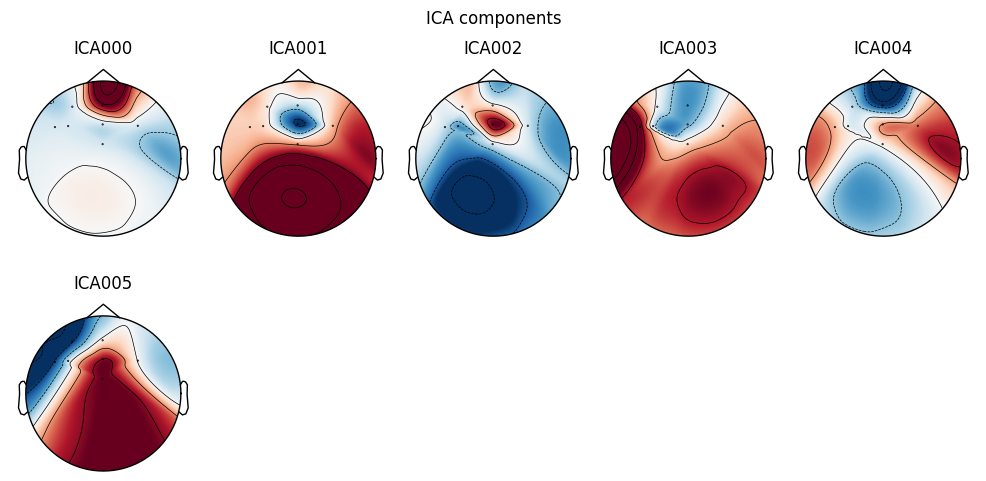

Creating RawArray with float64 data, n_channels=6, n_times=43285


    Range : 0 ... 43284 =      0.000 ...   173.136 secs


Ready.


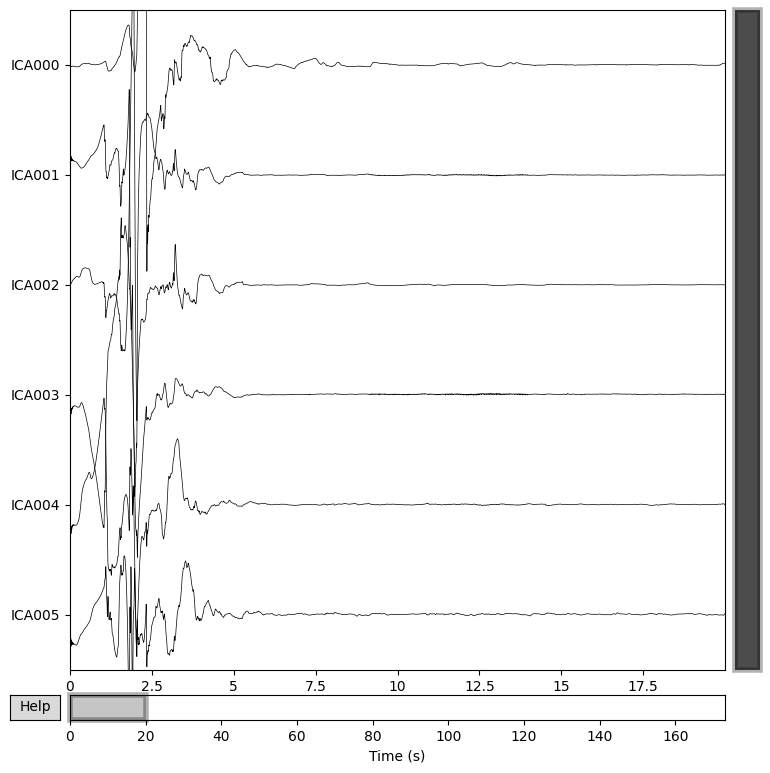

Applying ICA to Raw instance


    Transforming to ICA space (6 components)


    Zeroing out 4 ICA components


    Projecting back using 7 PCA components


In [33]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data

df = pd.DataFrame(eeg_raw.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')
df.drop(['Timestamp', 'Ch12'], axis = 1, inplace = True)

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
#raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1,2,3]  # don't know how to do this
raw_clean = ica.apply(raw.copy())



In [11]:
# lifu_on_time_onset is an array of times in seconds
event_samples = trials

# Build MNE event array: shape (n_events, 3)
# Columns: [sample_index, 0, event_id]
events = np.column_stack([event_samples, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])
tmin = -0.2
tmax = 0.8

epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=(-0.2, 0),     # or (-2, 0) if you want baseline correction
    preload=True
)


Not setting metadata


100 matching events found


Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 100 events and 251 original time points ...


0 bad epochs dropped


In [12]:
erp = epochs.average()
erp

<Evoked | '1' (average, N=100), -0.2 – 0.8 s, baseline -0.2 – 0 s, 7 ch, ~29 KiB>

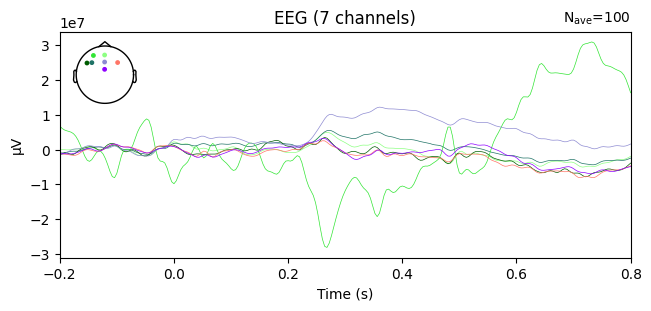

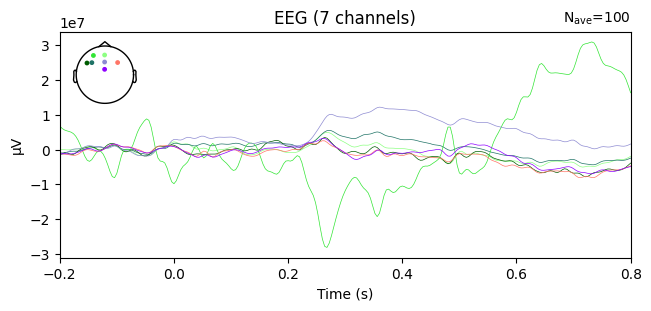

In [13]:
erp.plot()